In [19]:
# ==========================================
# CELL 1: SETUP & DRIVE MOUNT
# ==========================================
from google.colab import drive
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the Base Path to your project folder in Drive
BASE_PATH = "/content/drive/MyDrive/"

# 3. Constants & System Configuration
MAX_FREQ = 1000
TEST_FOLDERS = [os.path.join(BASE_PATH, "Test/A"),
                os.path.join(BASE_PATH, "Test/B"),
                os.path.join(BASE_PATH, "Test/C")]
CUSTOM_MOTOR_FOLDER = os.path.join(BASE_PATH, "Test") # Update if your motor data is in a subfolder
SAVED_MODEL_PATH = os.path.join(BASE_PATH, "Best_Model/Best_Robust_Model (4).keras")
LABELS = ['Healthy', 'Inner Race', 'Outer Race', 'BRB']

# 4. Helper Functions
def get_true_label_from_filename(filename):
    name_lower = filename.lower()
    if 'health' in name_lower or 'unload' in name_lower: return 0
    elif 'inner' in name_lower or 'ir' in name_lower: return 1
    elif 'outer' in name_lower or 'or' in name_lower: return 2
    elif 'brb' in name_lower or 'broken' in name_lower: return 3
    else: return -1

def get_window_size_from_folder(folder_name):
    if 'A' in folder_name: return 10000
    elif 'B' in folder_name: return 20000
    elif 'C' in folder_name: return 100000
    else: return 20000

@tf.custom_gradient
def grad_reverse(x, alpha=1.0):
    def custom_grad(dy): return -alpha * dy, None
    return tf.identity(x), custom_grad

class GradientReversal(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(GradientReversal, self).__init__(**kwargs)
        self.alpha = tf.Variable(0.0, trainable=False, dtype=tf.float32, name='alpha')
    def call(self, x): return grad_reverse(x, self.alpha)

def process_1_second_chunk(chunk):
    centered_chunk = chunk - np.mean(chunk, axis=0)
    fft_data = np.abs(np.fft.fft(centered_chunk, axis=0))
    fundamental_peaks = np.max(fft_data[10:100, :], axis=0)
    normalized_fft = fft_data / (fundamental_peaks + 1e-9)
    if normalized_fft.shape[0] < MAX_FREQ:
        padding = np.zeros((MAX_FREQ - normalized_fft.shape[0], 3))
        result = np.vstack((normalized_fft, padding))
    else:
        result = normalized_fft[:MAX_FREQ, :]
    return result

def process_live_csv(file_path, folder_window_size):
    df = pd.read_csv(file_path)
    df = df.select_dtypes(include=['number'])
    if 'Time' in df.columns: df = df.drop(columns=['Time'])
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    raw_data = df.values[:, :3]
    total_rows = len(raw_data)
    X_list, start_idx, step_size = [], 0, folder_window_size
    while (start_idx + folder_window_size) <= total_rows:
        chunk = raw_data[start_idx:start_idx + folder_window_size, :]
        X_list.append(process_1_second_chunk(chunk))
        start_idx += step_size
    return np.array(X_list, dtype=np.float32)

# Load the AI Model into memory
print(f"\nLoading Pre-Trained DANN Architecture...")
model = tf.keras.models.load_model(
    SAVED_MODEL_PATH,
    custom_objects={'GradientReversal': GradientReversal}
)
print("Setup Complete! Model Loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading Pre-Trained DANN Architecture...
Setup Complete! Model Loaded.


 PHASE 1: BENCHMARK DATASET VALIDATION

--- Universal Classification Report ---
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00         5
  Inner Race       0.86      0.86      0.86         7
  Outer Race       0.88      1.00      0.93         7
         BRB       1.00      0.75      0.86         4

    accuracy                           0.91        23
   macro avg       0.93      0.90      0.91        23
weighted avg       0.92      0.91      0.91        23



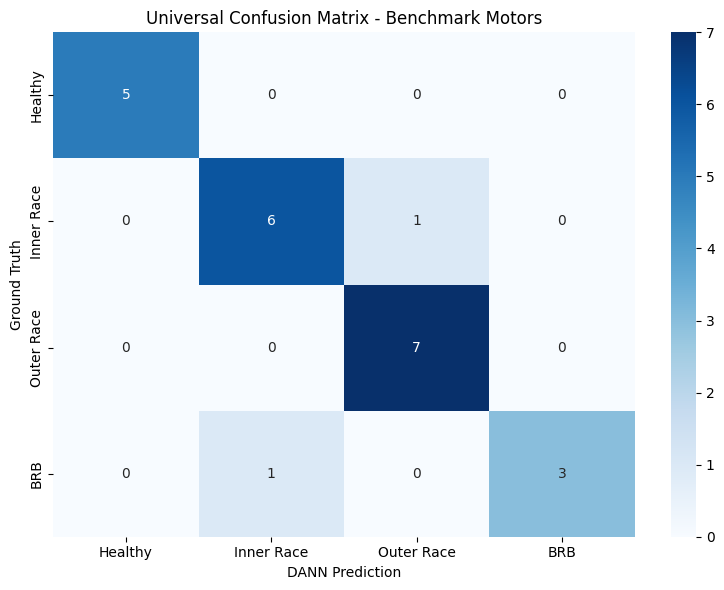

In [20]:
# ==========================================
# CELL 2: BENCHMARK TESTING
# ==========================================
y_true_all = []
y_pred_all = []

print("=======================================")
print(" PHASE 1: BENCHMARK DATASET VALIDATION")
print("=======================================")

for folder_path in TEST_FOLDERS:
    if not os.path.exists(folder_path):
        print(f"Skipping {folder_path} - Not found.")
        continue

    folder_window_size = get_window_size_from_folder(folder_path)

    for filename in os.listdir(folder_path):
        if not filename.endswith('.csv'): continue

        file_path = os.path.join(folder_path, filename)
        true_label = get_true_label_from_filename(filename)
        if true_label == -1: continue

        ready_to_predict_data = process_live_csv(file_path, folder_window_size)
        if len(ready_to_predict_data) == 0: continue

        predictions = model.predict(ready_to_predict_data, verbose=0)
        fault_probabilities = predictions[0]

        cumulative_confidences = np.sum(fault_probabilities, axis=0)
        majority_fault_idx = np.argmax(cumulative_confidences)

        y_true_all.append(true_label)
        y_pred_all.append(majority_fault_idx)

if len(y_true_all) > 0:
    print("\n--- Universal Classification Report ---")
    print(classification_report(y_true_all, y_pred_all, labels=[0, 1, 2, 3], target_names=LABELS, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1, 2, 3])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS)
    plt.title('Universal Confusion Matrix - Benchmark Motors')
    plt.ylabel('Ground Truth')
    plt.xlabel('DANN Prediction')
    plt.tight_layout()
    plt.show()
else:
    print("No valid benchmark CSV files were found to evaluate.")

In [21]:
# ==========================================
# CELL 3: REAL-WORLD MOTOR DEPLOYMENT (500Hz)
# ==========================================
print("=======================================")
print(" PHASE 2: CUSTOM MOTOR INFERENCE (500 Hz)")
print("=======================================")

if os.path.exists(CUSTOM_MOTOR_FOLDER):
    custom_fs = 500
    files_found = os.listdir(CUSTOM_MOTOR_FOLDER)
    print(f" -> Found {len(files_found)} total files in directory.\n")

    for filename in files_found:
        if not filename.endswith('.csv'): continue
        if 'motor' not in filename.lower(): continue # Only process files named "motor"

        file_path = os.path.join(CUSTOM_MOTOR_FOLDER, filename)

        ready_to_predict_data = process_live_csv(file_path, folder_window_size=custom_fs)

        if len(ready_to_predict_data) == 0:
            print(f"[!] '{filename}' has insufficient data duration (Requires > 1.0s).")
            continue

        predictions = model.predict(ready_to_predict_data, verbose=0)
        fault_probabilities = predictions[0]

        cumulative_confidences = np.sum(fault_probabilities, axis=0)
        majority_fault_idx = np.argmax(cumulative_confidences)

        print(f"File: {filename:<30} | Diagnosis: {LABELS[majority_fault_idx]}")

else:
    print(f" -> ERROR: Directory '{CUSTOM_MOTOR_FOLDER}' not found. Please check your Drive paths!")

 PHASE 2: CUSTOM MOTOR INFERENCE (500 Hz)
 -> Found 5 total files in directory.

File: Motor_data_Unload.csv          | Diagnosis: Healthy
File: Motor_data_Load.csv            | Diagnosis: Healthy
